In [1]:
import cleanup
import plotting
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
import tkinter
from tkinter import filedialog
import scipy as scp
import scipy.stats as scpst

pd.options.mode.use_inf_as_na = True

In [4]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df = cleanup.data_to_dataframe(filepath)

In [5]:
primary_df = primary_df[primary_df['Frame']<600]
primary_df = cleanup.calculate_distance_from_fixed_point(primary_df)
primary_df = cleanup.categorize_values(primary_df, 'X', 14, 1.5)

In [6]:
primary_df_interp = cleanup.interpolate_missing_values(primary_df)
primary_df_interp = cleanup.calculate_distance_from_fixed_point(primary_df_interp)

In [26]:
df_neighbour = cleanup.create_combined_real_simulated_df(df = primary_df_interp)

In [27]:
# for cond in primary_df_interp['Condition'].unique():
#     plotting.plot_trajectory_heatmaps(primary_df_interp, cond, frame_bin_size=100, grid_size=1)

In [7]:
#Defining subdataframes for analysis

df_EA = primary_df_interp[primary_df_interp['Odour'] == 'EA']
df_1P = primary_df_interp[primary_df_interp['Odour'] == '1P']
df_PA = primary_df_interp[primary_df_interp['Odour'] == 'PA']

df_crosses = primary_df_interp[(primary_df_interp['Genotype'] == 'TrhxKir') 
                              | (primary_df_interp['Genotype'] == 'CSDxKir')
                              | (primary_df_interp['Genotype'] == 'WTxCSD')
                              | (primary_df_interp['Genotype'] == 'WTxKir')
                              | (primary_df_interp['Genotype'] == 'WTxTrh')]

In [8]:
df_crosses_trh = primary_df_interp[(primary_df_interp['Genotype'] == 'TrhxKir') 
                              
                              
                              | (primary_df_interp['Genotype'] == 'WTxKir')
                              | (primary_df_interp['Genotype'] == 'WTxTrh')]

In [9]:
df_crosses_csd = primary_df_interp[
                              (primary_df_interp['Genotype'] == 'CSDxKir')
                              | (primary_df_interp['Genotype'] == 'WTxCSD')
                              
                              | (primary_df_interp['Genotype'] == 'WTxTrh')]

In [11]:
# plotting.plot_two_distance_by_condition_averages(df_crosses_trh[df_crosses_trh['Starvation'] == 'Fed'],
#                                                   df_crosses_trh[df_crosses_trh['Starvation'] == '5h'],
#                                                     titles=('TrhxKir and Controls - Fed', 
#                                                             'TrhxKir and Controls - 5h Starved'))

In [12]:
# plotting.plot_two_distance_by_condition_averages(df_crosses_csd[df_crosses_csd['Starvation'] == 'Fed'],
#                                                   df_crosses_csd[df_crosses_csd['Starvation'] == '5h'],
#                                                     titles=('CSDxKir and Controls - Fed', 
#                                                             'CSDxKir and Controls - 5h Starved'))

In [17]:
df_EA_sub = primary_df_interp[(primary_df_interp['Concentration'] == '10-4') 
             & (primary_df_interp['Genotype'] == 'Trh')
             & (primary_df_interp['Odour'] == 'EA')
             & (primary_df_interp['Collective'] == 'Group')]

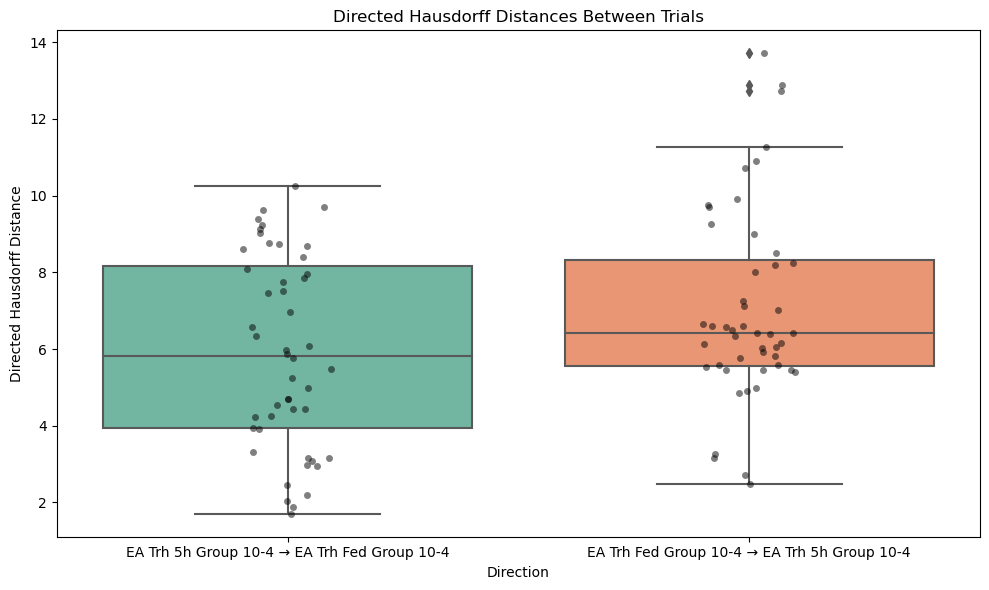

In [18]:
dhd_df = plotting.compute_and_plot_dhd(df_EA_sub)

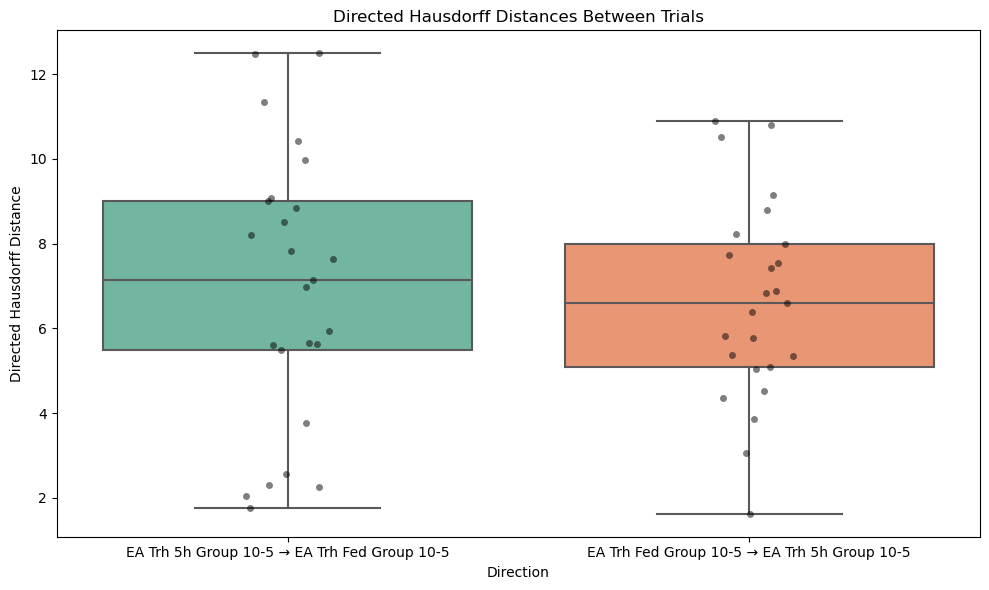

In [ ]:
df_PA_sub = primary_df_interp[(primary_df_interp['Concentration'] == '10-4') 
             & (primary_df_interp['Genotype'] == 'Trh')
             & (primary_df_interp['Odour'] == 'EA')
             & (primary_df_interp['Collective'] == 'Group')]

dhd_df = plotting.compute_and_plot_dhd(df_PA_sub)

In [ ]:
plotting.plot_preference_index_and_speed()

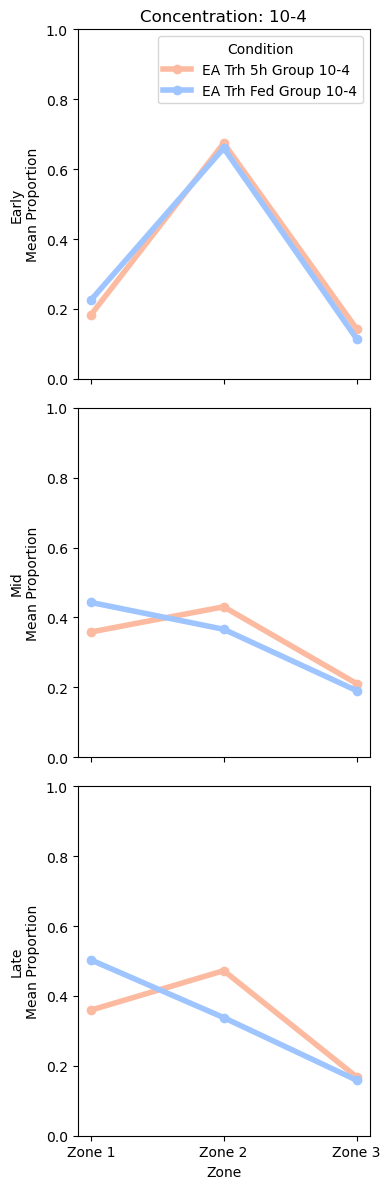

In [114]:
plotting.plot_zone_means_subplot(df_EA_sub)

In [ ]:
dfd_df = plotting.compute_and_plot_dhd(df_EA_sub)

              Condition  Frame  Proportion
0  EA Trh 5h Group 10-4   12.0         0.0
1  EA Trh 5h Group 10-4   13.0         0.0
2  EA Trh 5h Group 10-4   14.0         0.0
3  EA Trh 5h Group 10-4   15.0         0.0
4  EA Trh 5h Group 10-4   16.0         0.0
Index(['Condition', 'Frame', 'Proportion'], dtype='object')


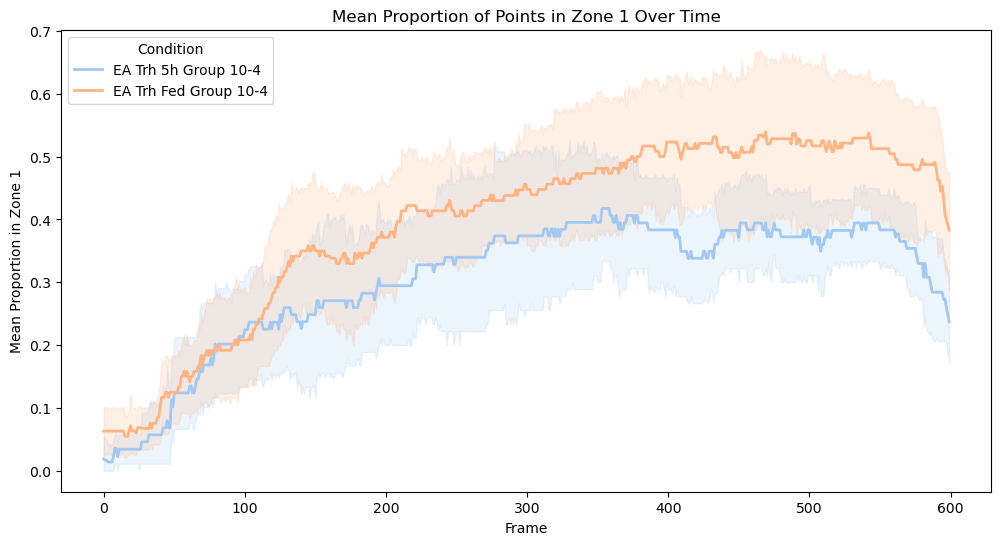

In [115]:
plotting.plot_zone_1_over_time(df_EA_sub) 

In [88]:
# plotting.plot_zone_means_subplot(df_PA_sub)

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:895: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.


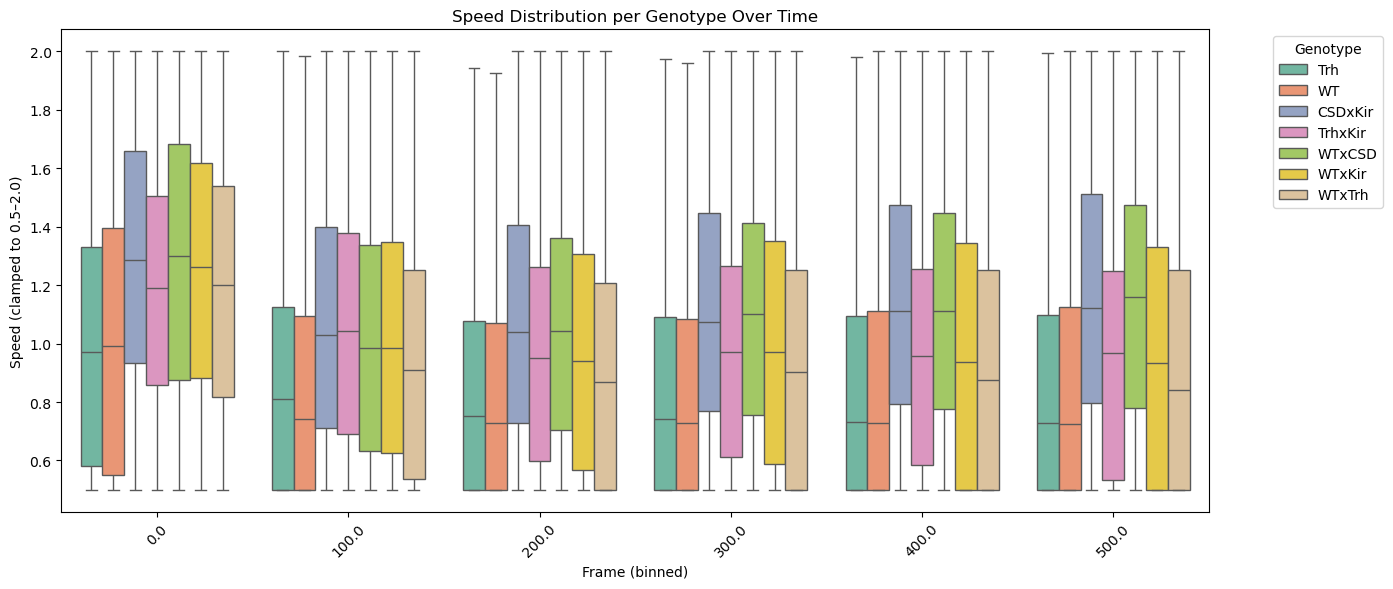

In [94]:
plotting.boxplot_speed_by_genotype(primary_df_interp)

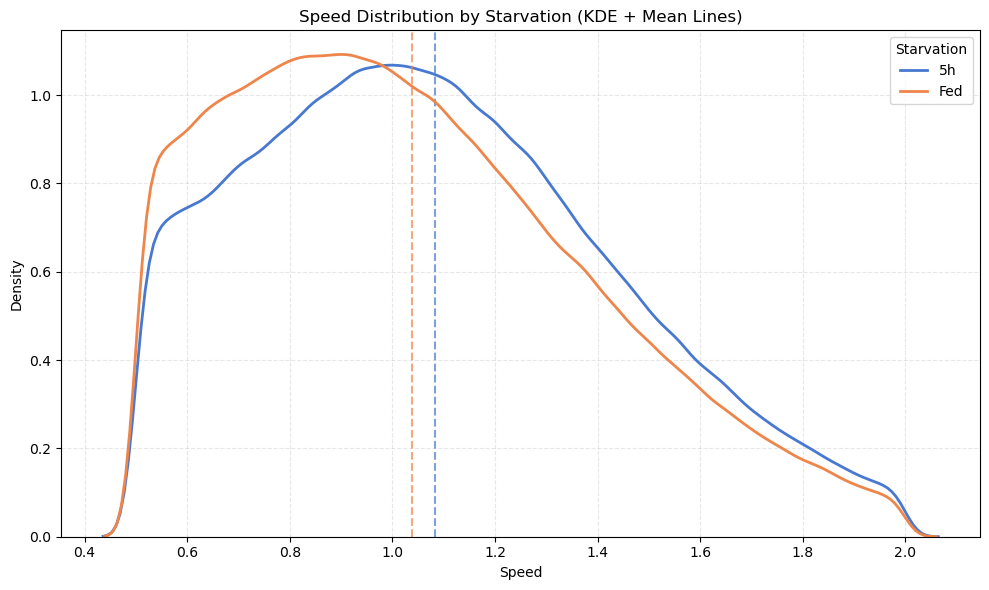

In [117]:
plotting.plot_speed_kde_by_starvation(primary_df_interp)

In [132]:
df_PA_sub = df_PA[(df_PA['Genotype'] == 'Trh') & (df_PA['Concentration'] == '10-4')]

In [129]:
# plotting.plot_zone_means_subplot(df_PA_sub)

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:1046: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.



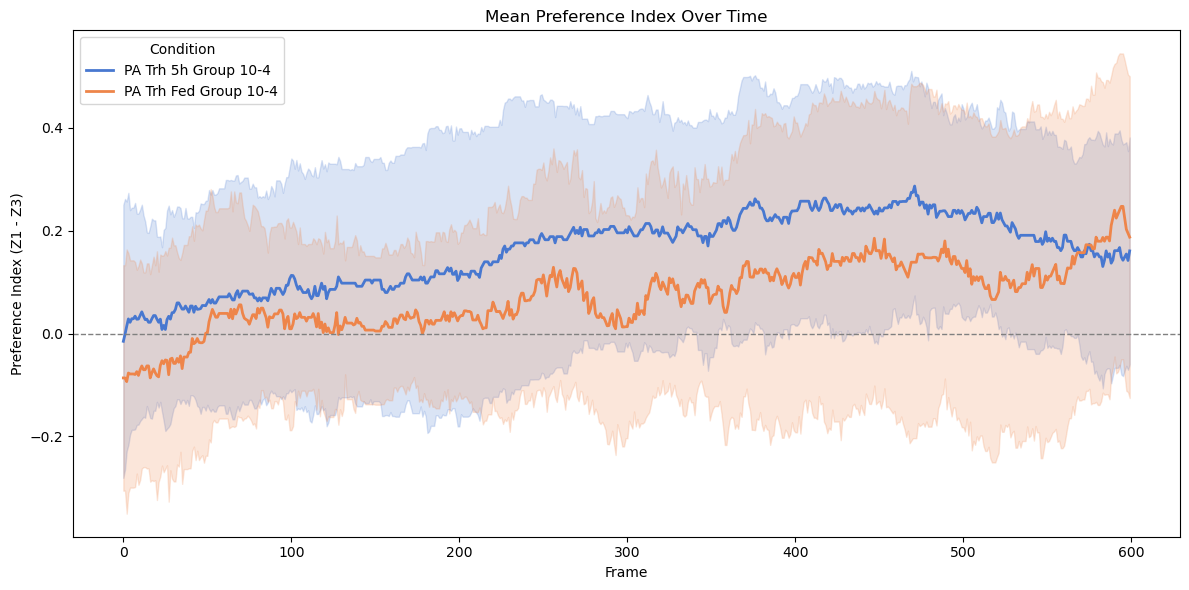

In [133]:
plotting.plot_preference_index_over_time(df_PA_sub) 

In [136]:
df_1P_sub = df_1P[(df_1P['Genotype'] == 'Trh') & (df_1P['Concentration'] == '10-2')]

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:1046: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.



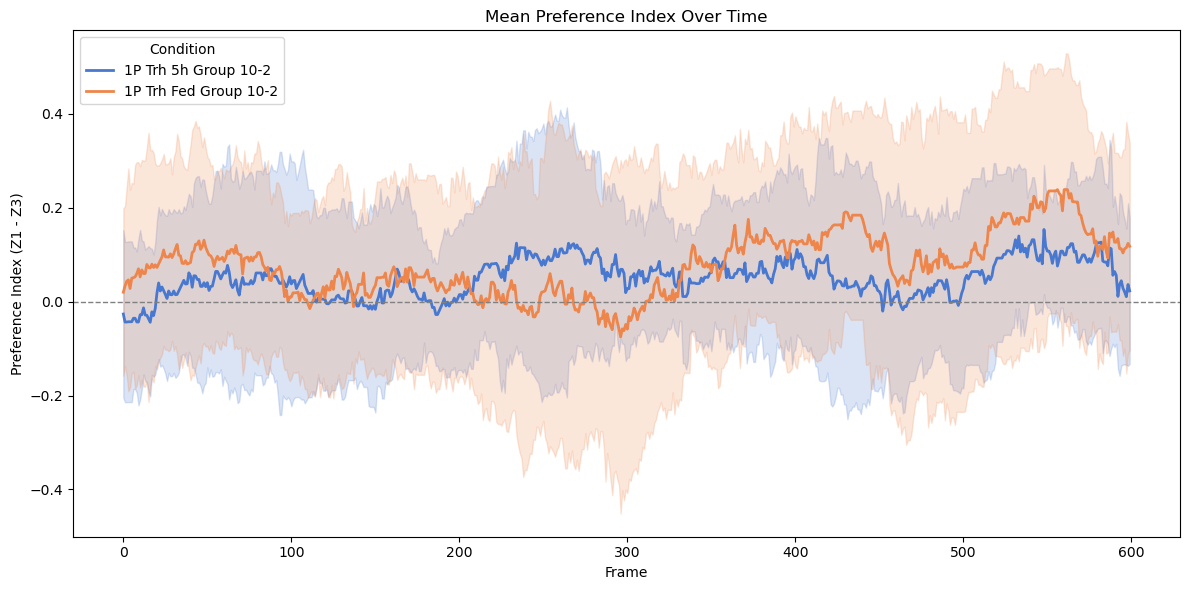

In [137]:
plotting.plot_preference_index_over_time(df_1P_sub) 